In [1]:
#自然言語処理用のgensimパッケージ
from gensim.models import KeyedVectors

file = '../../code/6/GoogleNews-vectors-negative300.bin'
#fileをword2vec形式で読み込み
model = KeyedVectors.load_word2vec_format(file,binary = True)


# 単語の取得
file = '../../code/6/countries.txt'                         #2行目に国名が含まれているカテゴリ                         
countries = set()                                                                       
with open(file, 'r', encoding='utf-8') as f:
    for row in f:
        if row.strip() in model:                  #modelに含まれている単語を取得                                                              
            countries.add(row.strip())                                     

countries = list(countries)                                                              
print(len(countries))
print(countries)

# 単語ベクトルの取得
countries_vec = [model[country] for country in countries]

177
['Georgia', 'Guatemala', 'Comoros', 'Namibia', 'United_States', 'Solomon_Islands', 'Barbados', 'Armenia', 'Portugal', 'Mexico', 'Czech_Republic', 'Korea', 'Bahrain', 'Togo', 'Lithuania', 'Vanuatu', 'Belarus', 'Fiji', 'United_Arab_Emirates', 'Germany', 'Iran', 'Indonesia', 'Spain', 'Egypt', 'France', 'Ireland', 'Yemen', 'Jordan', 'Micronesia', 'Brazil', 'Peru', 'Djibouti', 'Antigua_Barbuda', 'Uruguay', 'Seychelles', 'Nauru', 'Iraq', 'Sudan', 'Philippines', 'Cameroon', 'Rwanda', 'Benin', 'Poland', 'Andorra', 'Mozambique', 'Iceland', 'Kenya', 'Malaysia', 'Afghanistan', 'Marshall_Islands', 'Norway', 'Haiti', 'Ethiopia', 'Russian', 'Pakistan', 'Mauritania', 'Kuwait', 'Myanmar', 'Malta', 'Burkina_Faso', 'Equatorial_Guinea', 'Zambia', 'Morocco', 'Canada', 'Tuvalu', 'Paraguay', 'Cuba', 'Mauritius', 'Ghana', 'Turkey', 'Bolivia', 'Lebanon', 'Nigeria', 'Congo', 'Guyana', 'Slovakia', 'United_Kingdom', 'Chile', 'New_Zealand', 'Algeria', 'Azerbaijan', 'Romania', 'Singapore', 'Angola', 'Montenegr

In [2]:
from sklearn.cluster import KMeans
import numpy as np

# k-meansクラスタリング
kmeans = KMeans(n_clusters=5)                          #クラスタ数を5に設定
kmeans.fit(countries_vec)                              #作成した単語ベクトルをクラスタリング
for i in range(5):
    cluster = np.where(kmeans.labels_ == i)[0]         #クラスタのラベルがiのもののcontries_vecでの要素番号
    print('cluster', i)
    print(', '.join([countries[k] for k in cluster]))

cluster 0
Korea, Indonesia, Philippines, Malaysia, Pakistan, Myanmar, Singapore, Australia, Uzbekistan, China, Maldives, Bangladesh, Cambodia, Kyrgyzstan, Timor_Leste, Turkmenistan, Thailand, Brunei, Nepal, Mongolia, Tajikistan, India, Bhutan, Sri_Lanka, Japan
cluster 1
Georgia, United_States, Armenia, Portugal, Mexico, Czech_Republic, Lithuania, Belarus, Germany, Spain, France, Ireland, Brazil, Uruguay, Poland, Andorra, Iceland, Norway, Russian, Malta, Canada, Paraguay, Turkey, Bolivia, Slovakia, United_Kingdom, Chile, Azerbaijan, Romania, Montenegro, Estonia, Luxembourg, Austria, Colombia, Slovenia, Ukraine, Kazakhstan, Greece, Ecuador, Albania, Argentina, Switzerland, Croatia, Bosnia_Herzegovina, Venezuela, Netherlands, Denmark, Belgium, Sweden, Cyprus, Hungary, Italy, Moldova, Bulgaria, Serbia, Liechtenstein, Monaco, San_Marino, Latvia, Finland
cluster 2
Bahrain, United_Arab_Emirates, Iran, Egypt, Yemen, Jordan, Djibouti, Iraq, Afghanistan, Kuwait, Morocco, Lebanon, Algeria, Qatar,

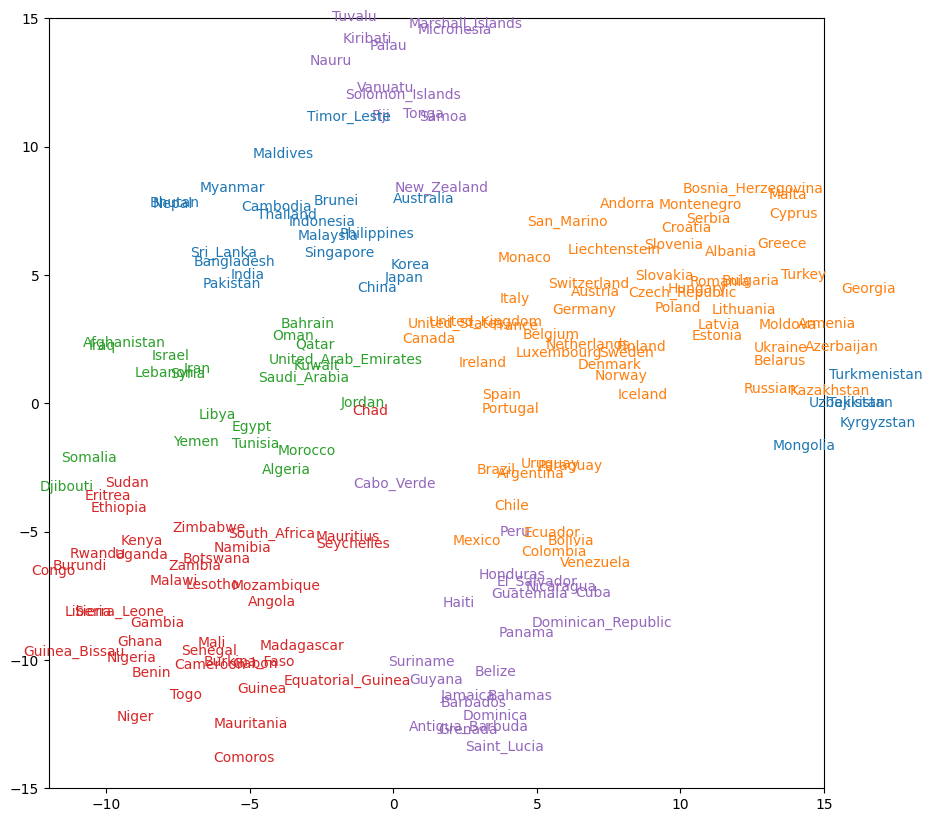

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=64)                                #t-SNEのインスタンスを作成
X_reduced = tsne.fit_transform(np.array(countries_vec))                     #次元削減処理
plt.figure(figsize=(10, 10))
for x, country, color in zip(X_reduced, countries, kmeans.labels_):
    plt.text(x[0], x[1], country, color='C{}'.format(color))                #引数は(x座標,y座標,テキスト)
plt.xlim([-12, 15])
plt.ylim([-15, 15])
plt.savefig('output6-9.png')
plt.show()